<a href="https://colab.research.google.com/github/kiriloivanov5-wq/ecommerce-data-analysis/blob/main/Portfolio_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
from concurrent.futures import ThreadPoolExecutor
from scipy.stats import normaltest, shapiro, pearsonr, mannwhitneyu, f_oneway
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Авторизація
auth.authenticate_user()

PROJECT_ID = 'data-analytics-mate'
DATASET_ID = 'DA'
client = bigquery.Client(project=PROJECT_ID)

# 2. СЛОВНИК ПОТРІБНИХ ТАБЛИЦЬ ТА СТОВПЦІВ
# Записано потрібні таблиці й стовпці:
required_columns = {
    'account': ['id', 'is_verified', 'is_unsubscribed'],
    'session': ['ga_session_id', 'date'],
    'session_params': ['ga_session_id', 'device', 'mobile_model_name', 'operating_system', 'browser', 'language', 'continent', 'country', 'channel', 'name'],
    'account_session': ['account_id', 'ga_session_id'],
    'order': ['ga_session_id', 'item_id'],
    'product': ['item_id', 'name', 'category', 'price', 'short_description']
}

dfs = {}

# 3. Функція завантаження однієї таблиці з вибраними стовпцями
def load_selected_table(table_name, columns):
    # Об'єднуємо список стовпців у рядок через кому: ['id', 'is_verified'] -> "id, is_verified"
    cols_str = ", ".join(columns)

    # Формується SQL-запит
    query = f"SELECT {cols_str} FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`"

    try:
        df = client.query(query).to_dataframe(create_bqstorage_client=False)
        print(f"✅ `{table_name}` завантажено: {df.shape[0]} рядків, стовпчики: {list(df.columns)}")
        return table_name, df
    except Exception as e:
        print(f"❌ Помилка при завантаженні `{table_name}`: {e}")
        return table_name, None

# 4. Паралельний запуск завантаження
print("Починаємо оптимізоване завантаження...\n")

with ThreadPoolExecutor(max_workers=5) as executor:
    # Запускаємо функцію для кожної пари (таблиця, стовпчики) зі словника
    futures = [executor.submit(load_selected_table, table, cols) for table, cols in required_columns.items()]

    for future in futures:
        table_name, df = future.result()
        if df is not None:
            dfs[table_name] = df

print("\n🚀 Всі вибрані таблиці успішно завантажені!")

Починаємо оптимізоване завантаження...

✅ `account_session` завантажено: 27945 рядків, стовпчики: ['account_id', 'ga_session_id']
✅ `order` завантажено: 33538 рядків, стовпчики: ['ga_session_id', 'item_id']
✅ `account` завантажено: 45831 рядків, стовпчики: ['id', 'is_verified', 'is_unsubscribed']
✅ `product` завантажено: 2962 рядків, стовпчики: ['item_id', 'name', 'category', 'price', 'short_description']
✅ `session` завантажено: 349545 рядків, стовпчики: ['ga_session_id', 'date']
✅ `session_params` завантажено: 349545 рядків, стовпчики: ['ga_session_id', 'device', 'mobile_model_name', 'operating_system', 'browser', 'language', 'continent', 'country', 'channel', 'name']

🚀 Всі вибрані таблиці успішно завантажені!


In [ ]:
df_account = dfs['account']
df_session = dfs['session']
df_session_params = dfs['session_params']
df_order = dfs['order']
df_product = dfs['product']
df_account_session = dfs['account_session']


In [ ]:
left_join1 = pd.merge(df_session, df_session_params, on = 'ga_session_id', how = 'left')
display(left_join1)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic)
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct)
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct)
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct)
...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral)
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic)
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct)
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted)


In [ ]:
left_join2 = pd.merge(left_join1, df_account_session, on = 'ga_session_id', how = 'left')
display(left_join2)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name,account_id
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>


In [ ]:
left_join3 = pd.merge(left_join2, df_account, left_on = 'account_id', right_on = 'id', how = 'left')
display(left_join3)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name,account_id,id,is_verified,is_unsubscribed
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>,<NA>,<NA>,<NA>
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>,<NA>,<NA>,<NA>
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>,<NA>,<NA>,<NA>
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>,<NA>,<NA>,<NA>
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>,<NA>,<NA>,<NA>
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>,<NA>,<NA>,<NA>
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>,<NA>,<NA>,<NA>
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>,<NA>,<NA>,<NA>


In [ ]:
delete_of_id = left_join3.drop(columns=['id'])
display(delete_of_id)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name,account_id,is_verified,is_unsubscribed
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>,<NA>,<NA>
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>,<NA>,<NA>
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>,<NA>,<NA>
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>,<NA>,<NA>
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>,<NA>,<NA>
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>,<NA>,<NA>
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>,<NA>,<NA>
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>,<NA>,<NA>


In [ ]:
left_join4 = pd.merge(delete_of_id, df_order, on = 'ga_session_id', how = 'left')
display(left_join4)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name,account_id,is_verified,is_unsubscribed,item_id
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>,<NA>,<NA>,99902661
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>,<NA>,<NA>,99902661
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>,<NA>,<NA>,20382932
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>,<NA>,<NA>,99902661
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>,<NA>,<NA>,99902661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>,<NA>,<NA>,<NA>
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>,<NA>,<NA>,<NA>
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>,<NA>,<NA>,<NA>
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>,<NA>,<NA>,<NA>


In [ ]:
left_join5 = pd.merge(left_join4, df_product, on = 'item_id', how = 'left')
df = left_join5.drop(columns = 'item_id')
display(df)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,name_x,account_id,is_verified,is_unsubscribed,name_y,category,price,short_description
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>,<NA>,<NA>,RÅSKOG,Tables & desks,189.0,"Trolley, 35x45x78 cm"
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN


In [ ]:
final_table = df.rename(columns = {'name_x': 'info_traffic', 'name_y': 'name_of_item'})
display(final_table)

,ga_session_id,date,device,mobile_model_name,operating_system,browser,language,continent,country,channel,info_traffic,account_id,is_verified,is_unsubscribed,name_of_item,category,price,short_description
0,5760483956,2020-11-01,desktop,Safari,Macintosh,Chrome,zh,Americas,United States,Paid Search,<Other>,<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,7115337200,2020-11-01,desktop,Chrome,Web,Chrome,en-us,Europe,United Kingdom,Organic Search,(organic),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,3978035233,2020-11-01,mobile,<Other>,Web,Chrome,zh,Europe,Norway,Direct,(direct),<NA>,<NA>,<NA>,RÅSKOG,Tables & desks,189.0,"Trolley, 35x45x78 cm"
3,9648986282,2020-11-01,mobile,<Other>,Android,Chrome,es-es,Africa,Nigeria,Direct,(direct),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,4393441533,2020-11-01,desktop,Chrome,Windows,Chrome,en-us,Asia,China,Direct,(direct),<NA>,<NA>,<NA>,VITTSJÖ,Bookcases & shelving units,609.0,"Shelving unit with laptop table, 202x36x175 cm"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,5756982967,2021-01-31,desktop,Firefox,Windows,Firefox,en-us,Europe,Ukraine,Social Search,(referral),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349541,464560636,2021-01-31,desktop,Edge,Web,Edge,en-us,Americas,United States,Organic Search,(organic),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349542,6336117447,2021-01-31,desktop,Chrome,Web,Chrome,en-us,Americas,United States,Direct,(direct),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
349543,4958826563,2021-01-31,mobile,iPhone,iOS,Safari,de,Asia,India,Undefined,(data deleted),<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN


In [ ]:
# Типи стовпців
final_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ga_session_id      349545 non-null  Int64  
 1   date               349545 non-null  dbdate 
 2   device             349545 non-null  object 
 3   mobile_model_name  349545 non-null  object 
 4   operating_system   349545 non-null  object 
 5   browser            349545 non-null  object 
 6   language           235279 non-null  object 
 7   continent          349545 non-null  object 
 8   country            349545 non-null  object 
 9   channel            349545 non-null  object 
 10  info_traffic       349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  name_of_item       33538 non-null   object 
 15  category           33538 non-null   object 
 16  pr

In [ ]:
# Кількість унікальних сесій
print(f"Кількість унікальних сесій: {final_table['ga_session_id'].nunique()}")

Кількість унікальних сесій: 349545


In [ ]:
# Часовий діапазон
print(f"Початок - {final_table['date'].min()}")
print(f"Кінець - {final_table['date'].max()}")

Початок - 2020-11-01
Кінець - 2021-01-31


In [ ]:
# Кількість пропущених значень по стовпцях
final_table.isna().sum(axis=0)

,0
ga_session_id,0
date,0
device,0
mobile_model_name,0
operating_system,0
browser,0
language,114266
continent,0
country,0
channel,0


Таблиця складається з 349545 рядків та 18 стовпців. Є 1 стовпець типу dbtime, 5 числових стовпців: ga_session_id, account_id, is_verified, is_unsubscribed, price, 10 категоріальних стовпців: device, mobile_model_name, operating_system, browser, language, continent, country, channel, name_of_item, category. 349545 унікальних сесій. Діапазон - від 1 листопада 2020 року до 31 січня 2021 року. Найбільше пропущених значень містять стовпці account_id, is_verified, is_unsubscribed, тому що маленька частка користувачів зареєструвалася на сайті.

In [ ]:
# Продажі та замовлення за континентами
sales_by_continent = final_table.groupby('continent')['price'].sum().reset_index().sort_values(by = 'price', ascending = False)
print("Продажі за континентами")
display(sales_by_continent.head(3))
orders_by_continent = final_table.groupby('continent')['name_of_item'].count().reset_index().sort_values(by = 'name_of_item', ascending = False)
print("\nЗамовлення за континентами")
display(orders_by_continent.head(3))

Продажі за континентами


,continent,price
2,Americas,17665280.0
3,Asia,7601298.3
4,Europe,5934624.2



Замовлення за континентами


,continent,name_of_item
2,Americas,18553
3,Asia,7950
4,Europe,6261


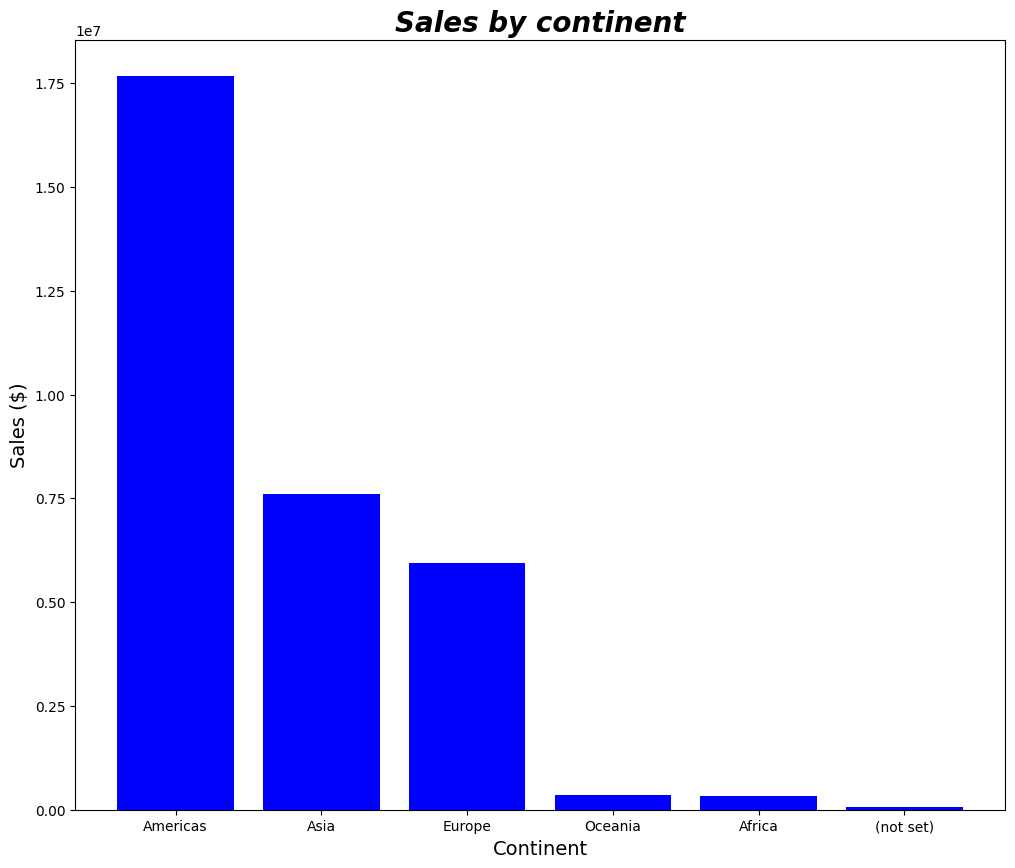

In [ ]:
plt.figure(figsize = (12, 10))
plt.bar(sales_by_continent['continent'], sales_by_continent['price'], color = 'blue')
plt.title('Sales by continent', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Continent', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

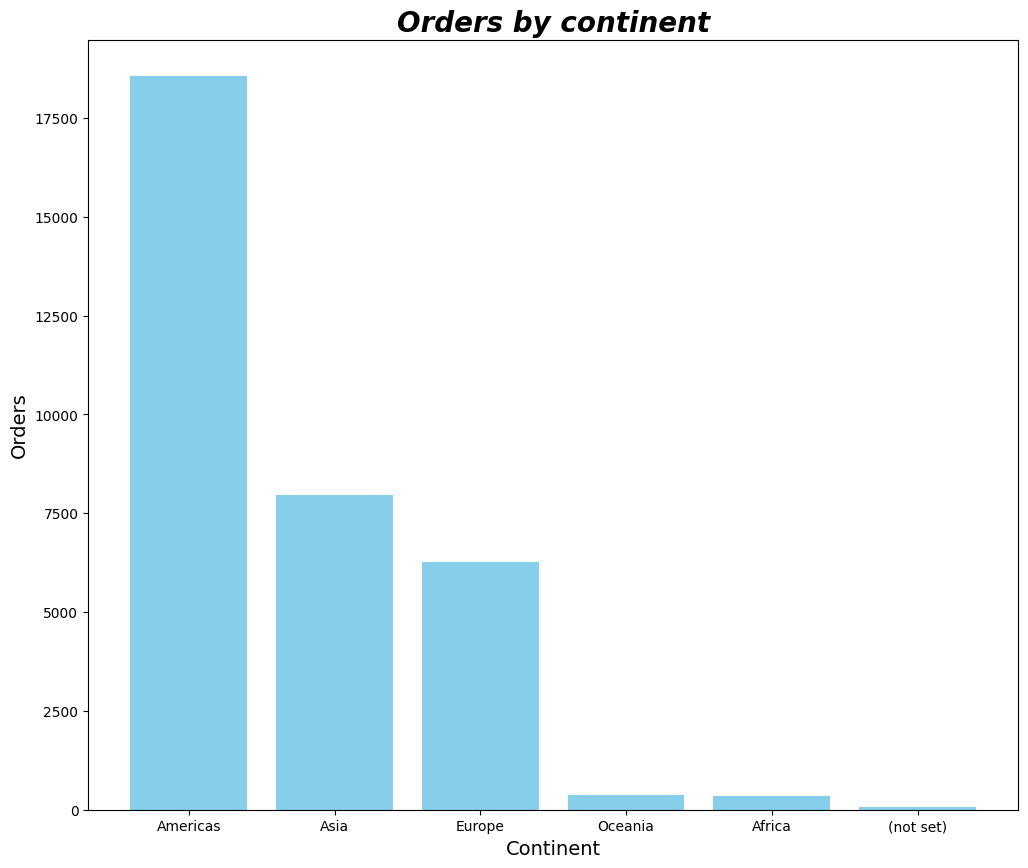

In [ ]:
plt.figure(figsize = (12, 10))
plt.bar(orders_by_continent['continent'], orders_by_continent['name_of_item'], color = 'skyblue')
plt.title('Orders by continent', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Continent', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Orders', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі та замовлення за країнами
sales_by_country = final_table.groupby('country')['price'].sum().reset_index().sort_values(by = 'price', ascending = False)
print("Продажі за країнами")
display(sales_by_country.head())
orders_by_country = final_table.groupby('country')['name_of_item'].count().reset_index().sort_values(by = 'name_of_item', ascending = False)
print("\nЗамовлення за країнами")
display(orders_by_country.head())

Продажі за країнами


,country,price
104,United States,13943553.9
43,India,2809762.0
18,Canada,2437921.0
103,United Kingdom,938317.9
33,France,710692.8



Замовлення за країнами


,country,name_of_item
104,United States,14673
43,India,3029
18,Canada,2560
103,United Kingdom,1029
33,France,678


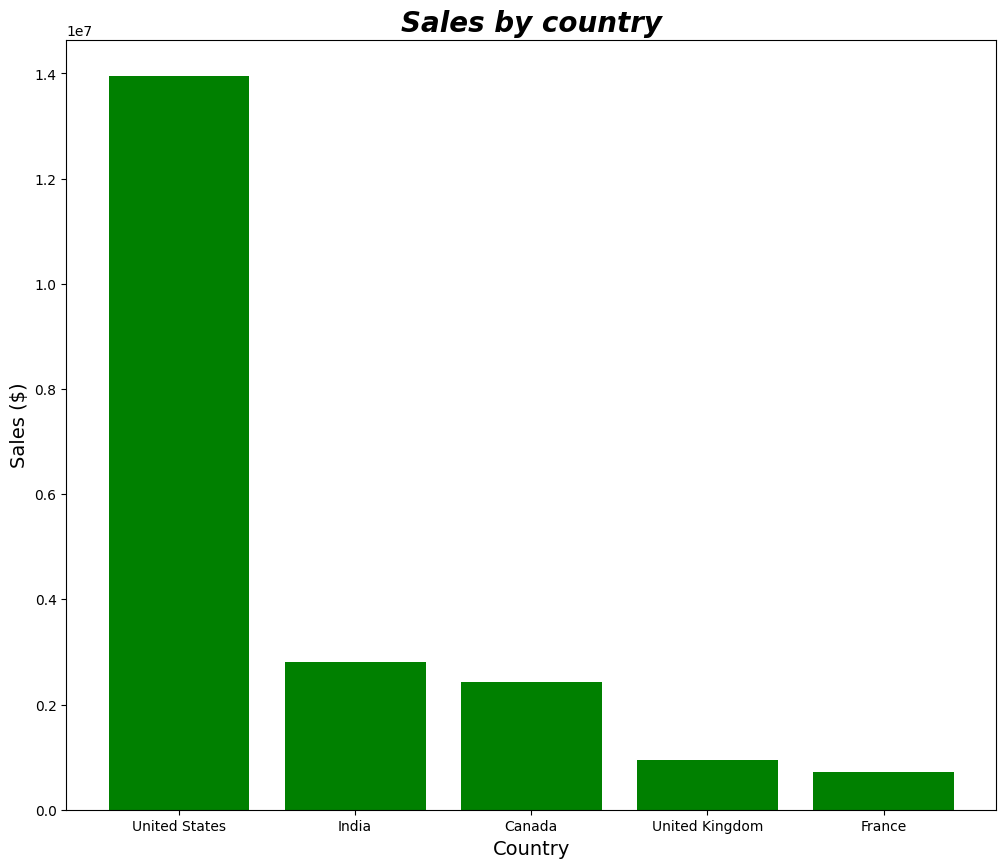

In [ ]:
five_countries_by_sales = sales_by_country[sales_by_country['country'].isin(['United States', 'India', 'Canada', 'United Kingdom', 'France'])]
plt.figure(figsize = (12, 10))
plt.bar(five_countries_by_sales['country'], five_countries_by_sales['price'], color = 'green')
plt.title('Sales by country', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Country', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

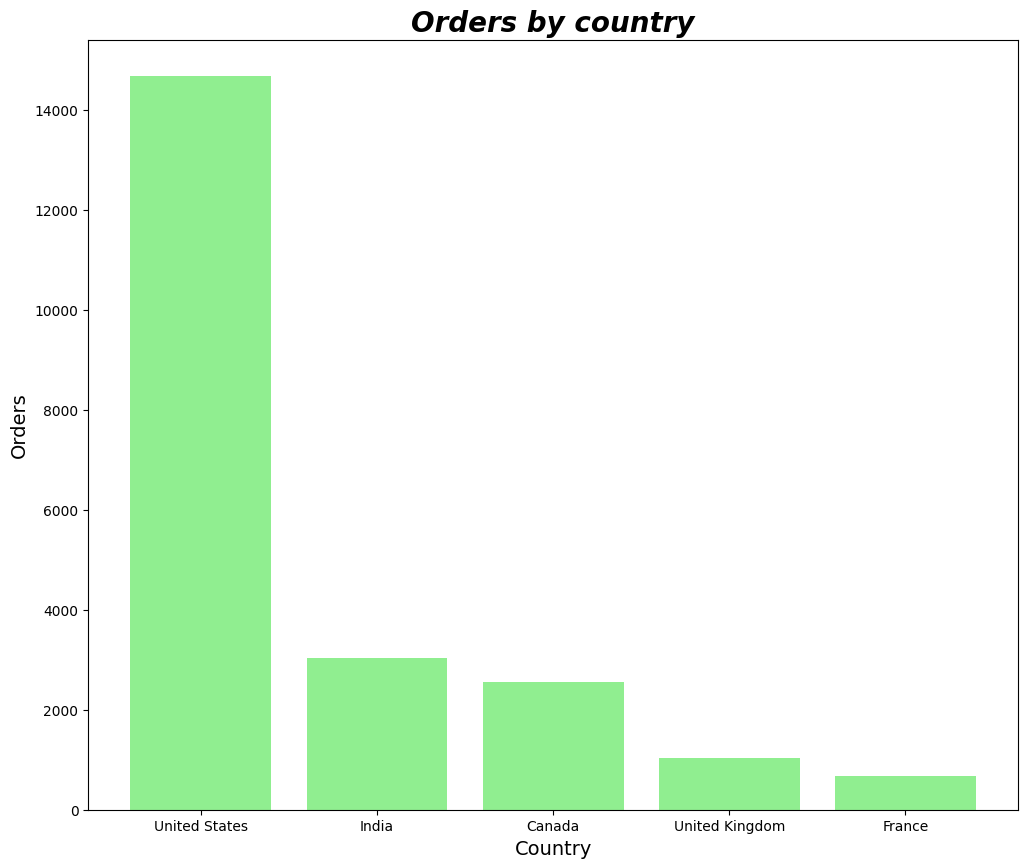

In [ ]:
five_countries_by_orders = orders_by_country[orders_by_country['country'].isin(['United States', 'India', 'Canada', 'United Kingdom', 'France'])]
plt.figure(figsize = (12, 10))
plt.bar(five_countries_by_orders['country'], five_countries_by_orders['name_of_item'], color = 'lightgreen')
plt.title('Orders by country', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Country', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Orders', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі за категоріями
sales_by_category = final_table.groupby('category')['price'].sum().reset_index().sort_values(by = 'price', ascending = False)
print("Продажі за категоріями")
display(sales_by_category.head(10))

Продажі за категоріями


,category,price
12,Sofas & armchairs,8388254.5
5,Chairs,6147748.8
1,Beds,4919725.0
2,Bookcases & shelving units,3640818.1
3,Cabinets & cupboards,2336499.5
9,Outdoor furniture,2142222.2
13,Tables & desks,1790307.5
6,Chests of drawers & drawer units,906562.5
0,Bar furniture,735503.0
7,Children's furniture,467697.0


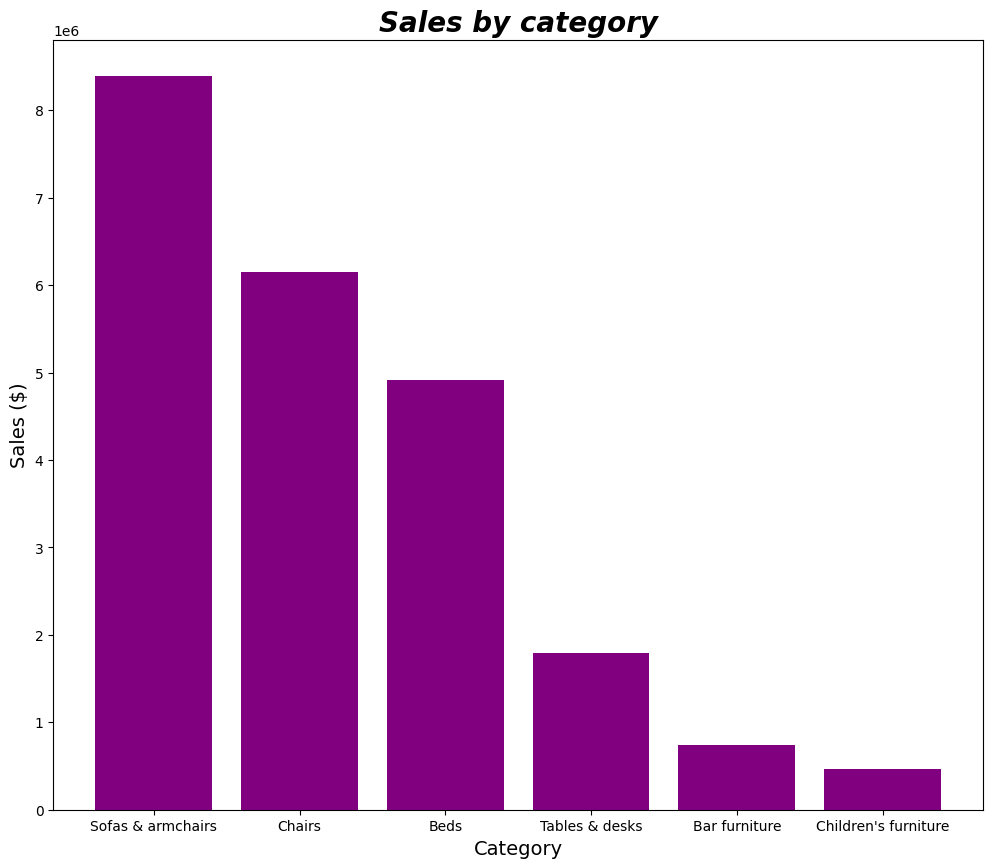

In [ ]:
categories_by_sales = sales_by_category[sales_by_category['category'].isin(['Sofas & armchairs', 'Chairs', 'Beds', 'Tables & desks', 'Bar furniture', 'Children\'s furniture' ])]
plt.figure(figsize = (12, 10))
plt.bar(categories_by_sales['category'], categories_by_sales['price'], color = 'purple')
plt.title('Sales by category', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Category', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі за категоріями в Сполучених Штатах Америки
sales_in_the_USA = final_table[final_table['country'].str.contains('United States')].groupby('category')['price'].sum().reset_index().sort_values(by = 'price', ascending = False)
display(sales_in_the_USA.head(10))

,category,price
12,Sofas & armchairs,3707144.5
5,Chairs,2619773.8
1,Beds,2213058.0
2,Bookcases & shelving units,1567606.9
3,Cabinets & cupboards,994545.5
9,Outdoor furniture,929245.2
13,Tables & desks,777865.0
6,Chests of drawers & drawer units,382388.0
0,Bar furniture,330805.0
7,Children's furniture,207575.0


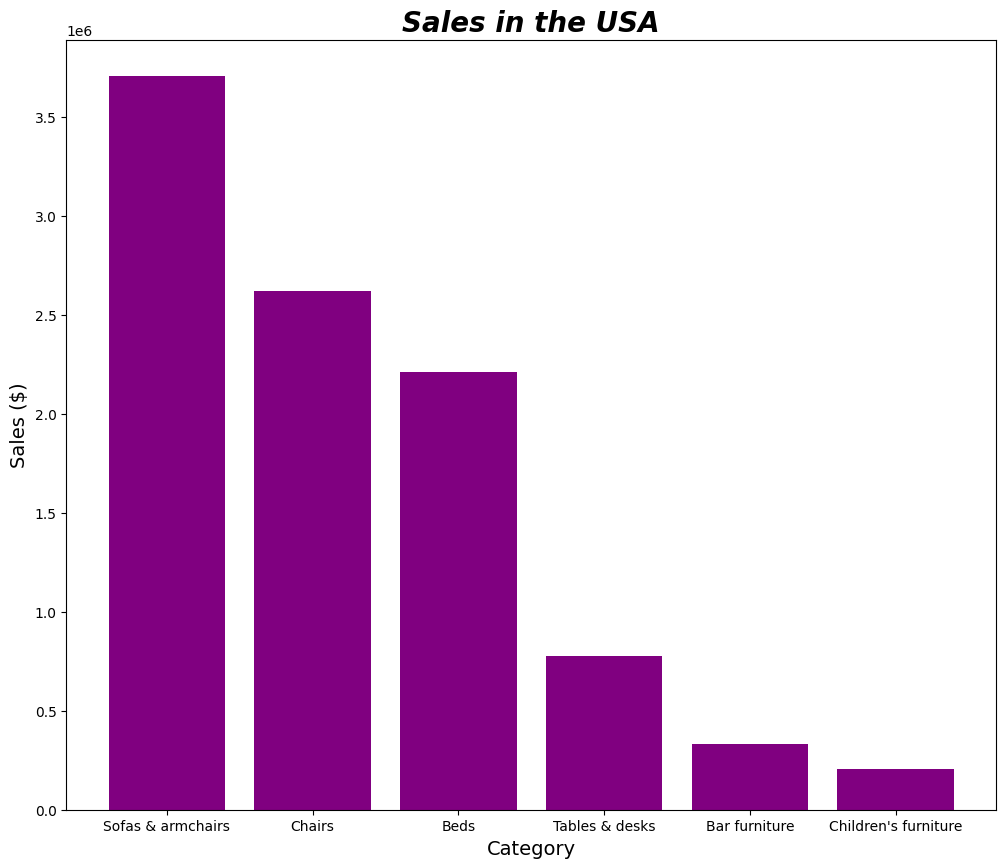

In [ ]:
categories_in_the_USA = sales_in_the_USA[sales_in_the_USA['category'].isin(['Sofas & armchairs', 'Chairs', 'Beds', 'Tables & desks', 'Bar furniture', 'Children\'s furniture' ])]
plt.figure(figsize = (12, 10))
plt.bar(categories_in_the_USA['category'], categories_in_the_USA['price'], color = 'purple')
plt.title('Sales in the USA', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Category', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі за категоріями
orders_by_category = final_table.groupby('category')['name_of_item'].count().reset_index().sort_values(by = 'name_of_item', ascending = False)
print("Замовлення за категоріями")
display(orders_by_category.head(10))

Замовлення за категоріями


,category,name_of_item
2,Bookcases & shelving units,7630
5,Chairs,5952
12,Sofas & armchairs,4301
13,Tables & desks,2941
1,Beds,2926
3,Cabinets & cupboards,2318
9,Outdoor furniture,2229
7,Children's furniture,1702
6,Chests of drawers & drawer units,1452
0,Bar furniture,1092


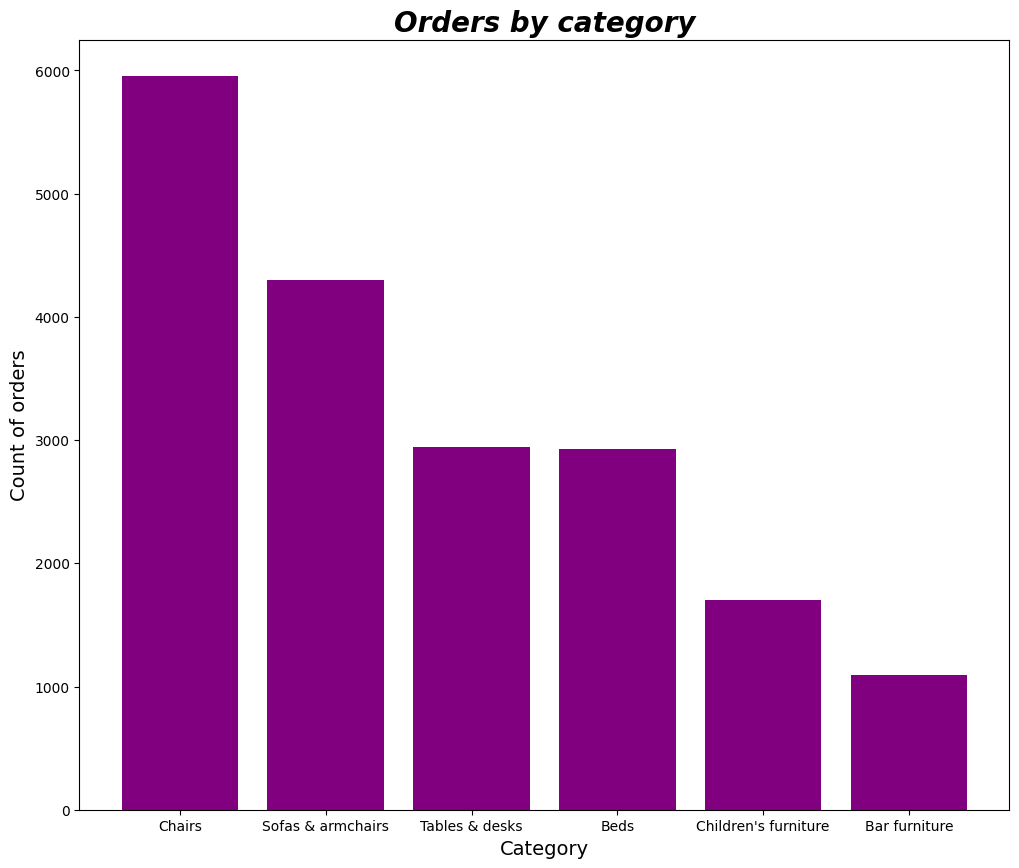

In [ ]:
categories_by_orders = orders_by_category[orders_by_category['category'].isin(['Sofas & armchairs', 'Chairs', 'Beds', 'Tables & desks', 'Bar furniture', 'Children\'s furniture' ])]
plt.figure(figsize = (12, 10))
plt.bar(categories_by_orders['category'], categories_by_orders['name_of_item'], color = 'purple')
plt.title('Orders by category', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Category', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Count of orders', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі за девайсом та моделлю
sales_by_device_and_model = final_table.groupby(['device', 'mobile_model_name'])['price'].sum().reset_index().sort_values(by = ['device', 'price'], ascending = [True, False])
sales_by_device_and_model['percentage'] = sales_by_device_and_model['price'] / sales_by_device_and_model['price'].sum() * 100
display(sales_by_device_and_model)

,device,mobile_model_name,price,percentage
1,desktop,Chrome,8899523.9,27.835602
5,desktop,Safari,6490467.1,20.300643
2,desktop,ChromeBook,1830458.7,5.725241
3,desktop,Edge,696877.3,2.179667
0,desktop,<Other>,525645.1,1.644093
4,desktop,Firefox,421066.9,1.316998
11,mobile,iPhone,6420776.3,20.082667
6,mobile,<Other>,5735073.6,17.937951
9,mobile,Pixel 4 XL,118287.7,0.369976
8,mobile,Pixel 3,109148.2,0.341390


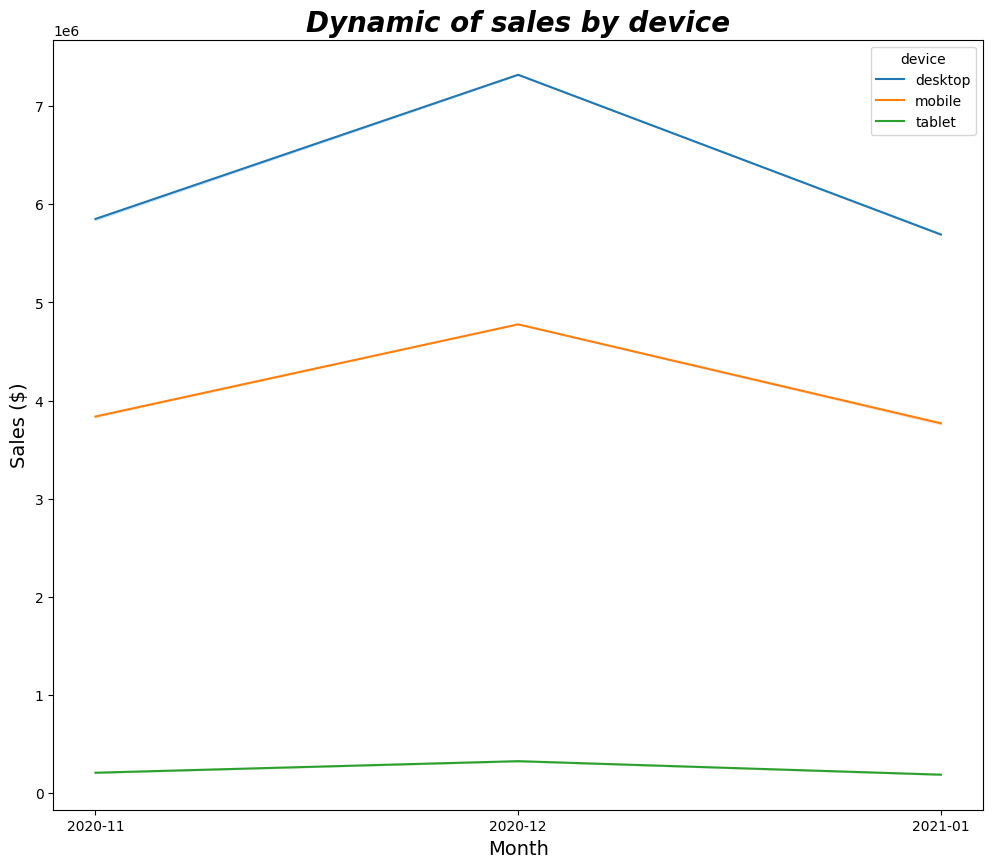

In [ ]:
final_table['date'] = pd.to_datetime(final_table['date'])
final_table["Month"] = final_table["date"].dt.to_period('M')
plt.figure(figsize = (12, 10))
sns.lineplot(data = final_table, x = final_table['Month'].astype(str), y = 'price', hue = 'device', errorbar=("ci", False), estimator = np.sum)
plt.title('Dynamic of sales by device', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Month', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Продажі за трафіком
sales_by_channel = final_table.groupby('channel')['price'].sum().reset_index().sort_values(by = 'price', ascending = False)
sales_by_channel['percentage'] = sales_by_channel['price'] / sales_by_channel['price'].sum() * 100
display(sales_by_channel)

,channel,price,percentage
1,Organic Search,11433151.6,35.760189
2,Paid Search,8511049.4,26.620546
0,Direct,7494923.4,23.442345
3,Social Search,2532105.7,7.919827
4,Undefined,2000501.0,6.257093


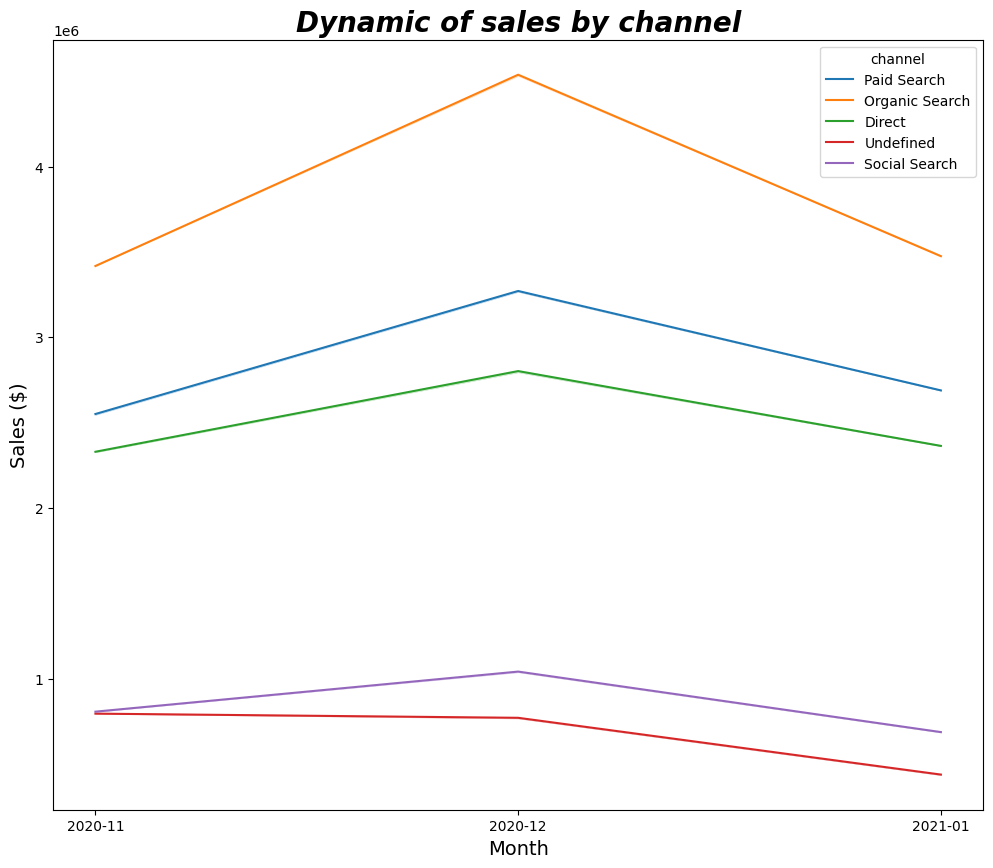

In [ ]:
plt.figure(figsize = (12, 10))
sns.lineplot(data = final_table, x = final_table['Month'].astype(str), y = 'price', hue = 'channel', errorbar=("ci", False), estimator = np.sum)
plt.title('Dynamic of sales by channel', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Month', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Зареєстровані користувачі, які відписалися від розсилки та підтвердили пошту
registered_users = final_table[final_table['account_id'].notna()]
print(f"Кількість зареєстрованих користувачів: {registered_users['account_id'].count()}")
unsubsribed_user = registered_users[registered_users['is_unsubscribed'] == 1]
print(f"Кількість зареєстрованих користувачів, які відписалися: {unsubsribed_user['is_unsubscribed'].count()}")
percentage_of_unsubscribed = unsubsribed_user['is_unsubscribed'].count() / registered_users['account_id'].count() * 100
print(f"Відсоток зареєстрованих користувачів, які відписалися: {percentage_of_unsubscribed}")
verified_us = registered_users[registered_users['is_verified'] == 1]
print(f"Кількість зареєстрованих користувачів, які підтвердили пошту: {verified_us['is_unsubscribed'].count()}")
percentage_of_verified_users = verified_us['is_verified'].count() / registered_users['account_id'].count() * 100
print(f"Відсоток зареєстрованих користувачів, які підтвердили пошту: {percentage_of_verified_users}")

Кількість зареєстрованих користувачів: 27945
Кількість зареєстрованих користувачів, які відписалися: 4735
Відсоток зареєстрованих користувачів, які відписалися: 16.94399713723385
Кількість зареєстрованих користувачів, які підтвердили пошту: 20036
Відсоток зареєстрованих користувачів, які підтвердили пошту: 71.69797817140812


In [ ]:
# Зареєстровані користувачі за браузерами
registration = final_table[final_table['account_id'].notna()].groupby('browser')['account_id'].count().reset_index().sort_values(by = 'account_id', ascending = False)
display(registration)

,browser,account_id
2,Chrome,19087
5,Safari,6595
0,<Other>,730
3,Edge,673
4,Firefox,490
1,Android Webview,370


In [ ]:
# Порівняння відписаних та невідписаних користувачів
sales_by_subscribed = final_table.groupby('is_unsubscribed')['price'].sum().reset_index()
display(sales_by_subscribed)

,is_unsubscribed,price
0,0,2150796.9
1,1,431721.6


In [ ]:
# Зареєстровані користувачі за країною
registration_by_country = final_table[final_table['account_id'].notna()].groupby('country')['account_id'].count().reset_index().sort_values(by = 'account_id', ascending = False)
display(registration_by_country)

,country,account_id
104,United States,12384
43,India,2687
18,Canada,2067
103,United Kingdom,859
33,France,553
...,...,...
39,Honduras,4
77,Paraguay,4
64,Mongolia,4
98,Trinidad & Tobago,4


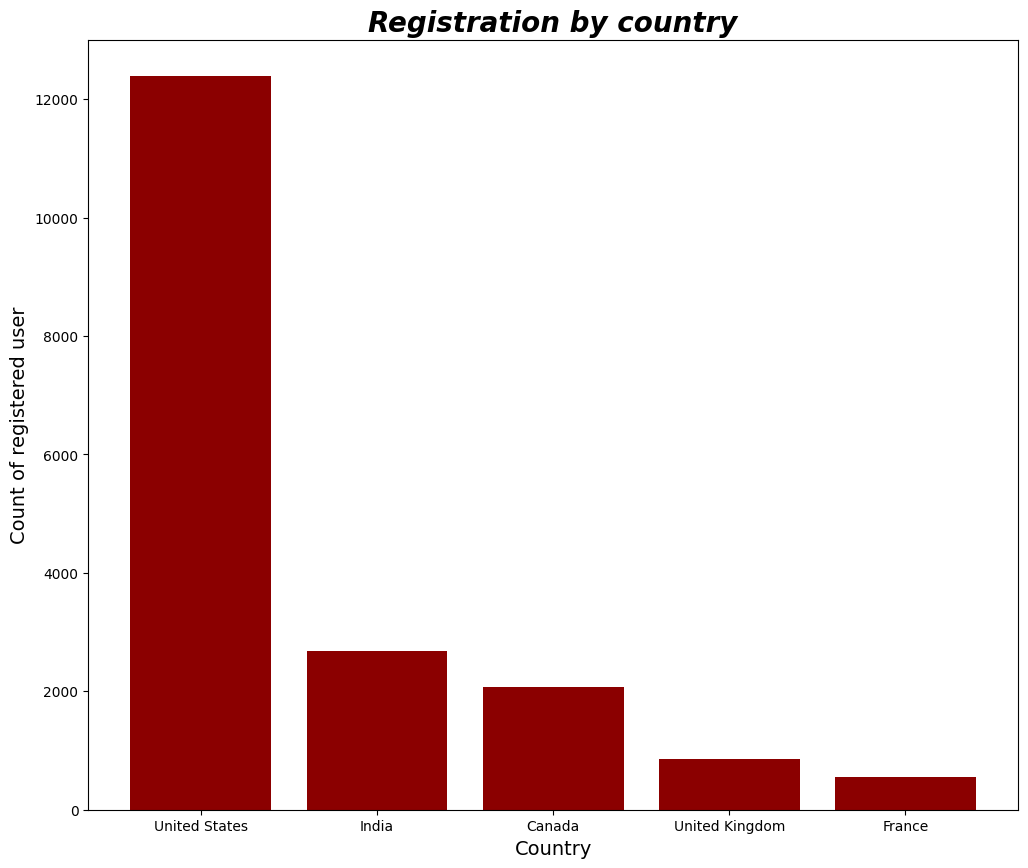

In [ ]:
five_countries_by_registration = registration_by_country[registration_by_country['country'].isin(['United States', 'India', 'Canada', 'United Kingdom', 'France'])]
plt.figure(figsize = (12, 10))
plt.bar(five_countries_by_registration['country'], five_countries_by_registration['account_id'], color = 'darkred')
plt.title('Registration by country', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Country', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Count of registered user', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
verified_users = final_table[final_table['is_verified'].notna()].groupby(['operating_system', 'is_verified'])['account_id'].count().reset_index()
display(verified_users)

,operating_system,is_verified,account_id
0,<Other>,0,184
1,<Other>,1,475
2,Android,0,634
3,Android,1,1661
4,Macintosh,0,554
5,Macintosh,1,1448
6,Web,0,4687
7,Web,1,11750
8,Windows,0,953
9,Windows,1,2392


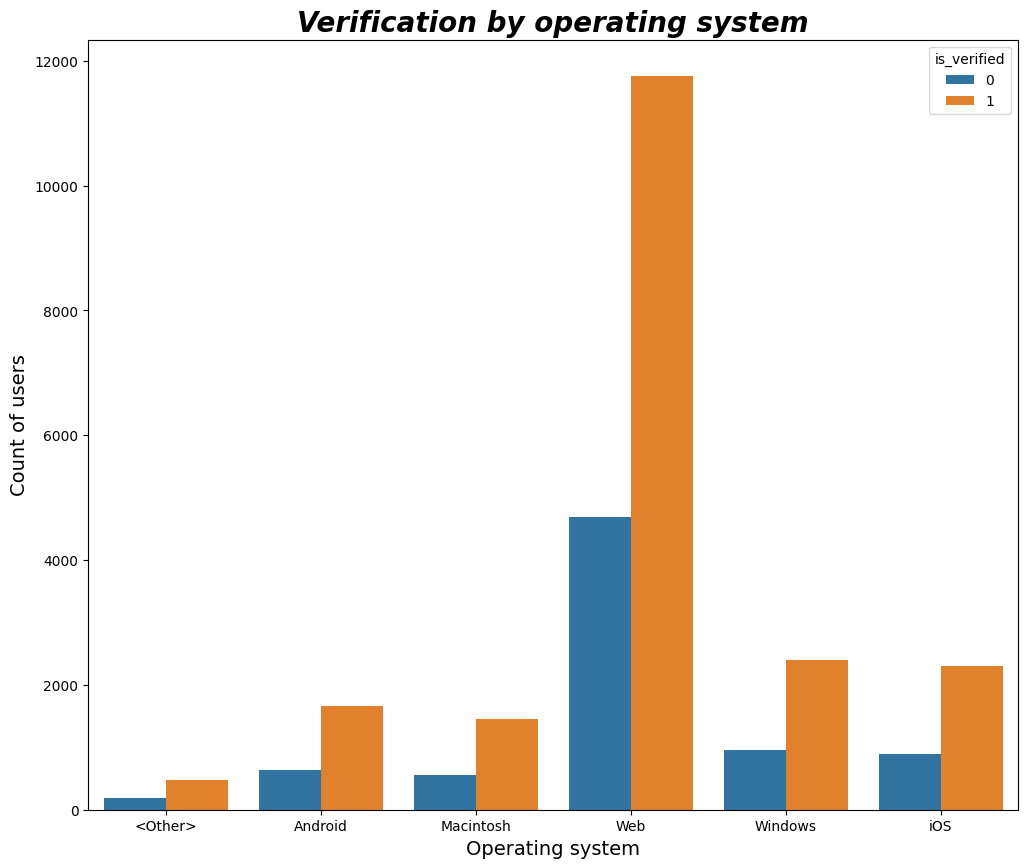

In [ ]:
plt.figure(figsize = (12, 10))
sns.barplot(data = verified_users, x = 'operating_system', y = 'account_id', hue = 'is_verified', errorbar=("ci", False), estimator = np.sum)
plt.title('Verification by operating system', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Operating system', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Count of users', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

Інсайти:
 1. Америка, Азія та Європа мають найбільші продажі та найбільше замовлень серед континентів.
 2. Сполучені Штати Америки, Індія, Канада, Велика Британія, Франція мають найбільші продажі та найбільше замовлень серед континентів.
 3. Товари категорій Sofas & armchairs, Chairs, Beds, Tables & desks, Bar furniture, Children's furniture входять у десятку тих, які приносять найбільший дохід, як по світу, так і по США.
 4. Серед десктопів забезпечує найбільший дохід модель Chrome (27% від усіх продажів), а найменший - модель FireFox (1.3%). Cеред мобайлів забезпечує найбільший дохід модель iPhone (20%), а найменший - модель Safari (майже 0%). Серед планшетів забезпечує найбільший дохід модель iPad (1.4%), а найменший - інші моделі (близько 1%).
 5. У розрізі каналів найбільший дохід забезпечує Органічний канал (36%) і найменший дохід забезпечує невизначений канал (6%).
 6. Із 349545 користувачів лише 27945 зареєструвалося, що складає 8%. Серед зареєстрованих користувачів відписалося від розсилки 4735, що складає близько 17%, а 20036 користувачів (близько 72%) підтвердили пошту.
 7. У розрізі браузерів найбільше зареєстрованих у браузерах Chrome (19087), Safari (майже 6600), а найменше - у браузерах Edge (673), Firefox (490), Android Webview (370).
 8. Невідписані користувачі приносять більше грошей, ніж відписані.
 9. Країни з великою кількістю зареєстрованих користувачів: США, Індія, Канада, Велика Британія, Франція. Країни з дуже маленькою кількістю зареєстрованих користувачів: Гондурас, Парагвай, Монголія, Тринідад і Табаго, Бахрейн.
 10. Найбільше користувачів зареєструвалося на таких операційних системах як Web, Windows, iOS. А от на операційних системах Android, Macintosh мало користувачів зареєструвалося.

In [ ]:
# Зведена таблиця про сесії за каналами та девайсами
pivot_table_by_channel_device = pd.pivot_table(final_table, values = 'ga_session_id', index = 'channel', columns = 'device', aggfunc = 'count')
display(pivot_table_by_channel_device)

device,desktop,mobile,tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
# Зведена таблиця про продажі за топ-10 категоріями та топ-5 країнами
ten_categories_five_countries = final_table[(final_table['category'].isin(['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Chests of drawers & drawer units', 'Tables & desks', 'Bar furniture', 'Children\'s furniture']) & final_table['country'].isin(['United States', 'India', 'Canada', 'United Kingdom', 'France']))]
pivot_table_by_category_country = pd.pivot_table(ten_categories_five_countries, values = 'price', index = 'category', columns = 'country', aggfunc = 'sum')
display(pivot_table_by_category_country)

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [ ]:
# Зведена таблиця про зареєстрованих користувачів за операційною системою та браузером
pivot_table_by_OS_browser = pd.pivot_table(final_table, values = 'account_id', index = 'operating_system', columns = 'browser', aggfunc = 'count', fill_value = 0)
display(pivot_table_by_OS_browser)

browser,<Other>,Android Webview,Chrome,Edge,Firefox,Safari
operating_system,,,,,,
<Other>,3,0,640,0,15,1
Android,189,91,2001,0,14,0
Macintosh,2,0,1474,1,30,495
Web,437,279,11767,438,289,3227
Windows,76,0,2893,234,142,0
iOS,23,0,312,0,0,2872


In [ ]:
grouped_by_date = final_table.groupby('date').agg(count_session = ('ga_session_id', 'count'), sales = ('price', 'sum'))
display(grouped_by_date)

,count_session,sales
date,,
2020-11-01,2576,244292.5
2020-11-02,3599,355506.8
2020-11-03,5173,498979.6
2020-11-04,4184,339187.1
2020-11-05,3743,391276.6
...,...,...
2021-01-27,4435,286340.7
2021-01-28,4112,0.0
2021-01-29,3700,0.0


In [ ]:
# Приберу дати, у які sales = 0
grouped_by_date_updated = grouped_by_date[grouped_by_date['sales'] != 0]
display(grouped_by_date_updated)

,count_session,sales
date,,
2020-11-01,2576,244292.5
2020-11-02,3599,355506.8
2020-11-03,5173,498979.6
2020-11-04,4184,339187.1
2020-11-05,3743,391276.6
...,...,...
2021-01-23,3067,290605.5
2021-01-24,2893,243818.4
2021-01-25,3760,305089.3


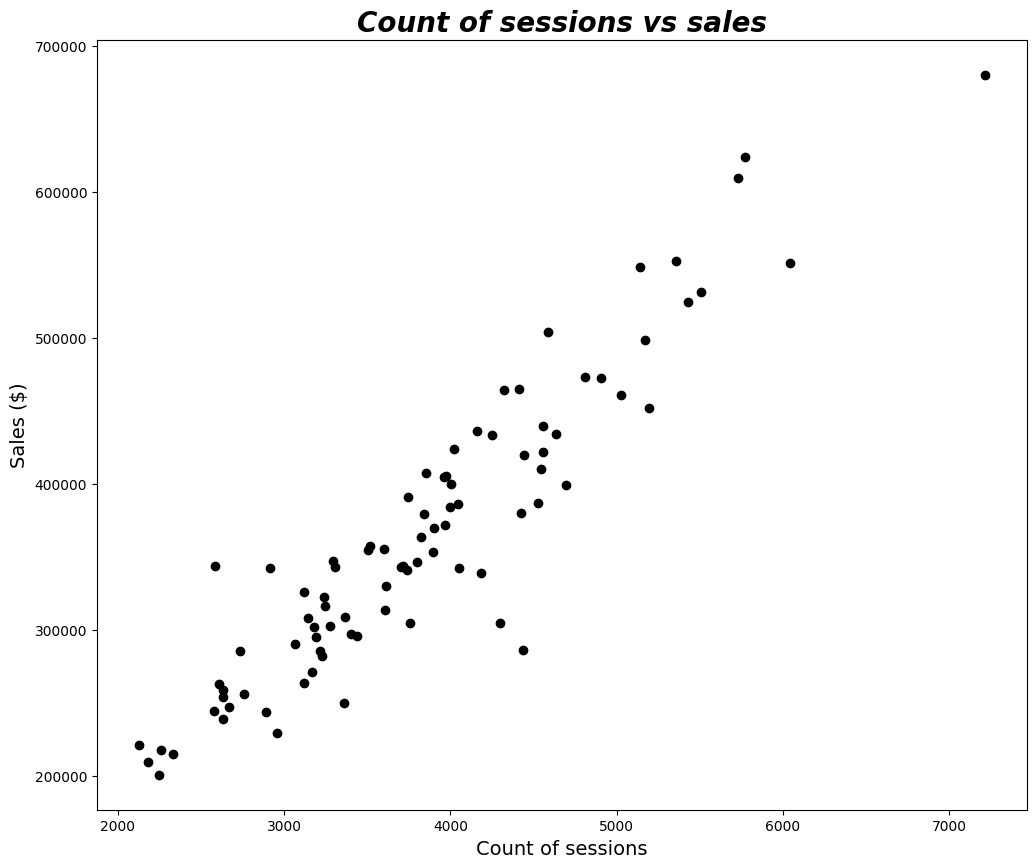

In [ ]:
# Кореляція між кількістю сесій та продажем за датою
plt.figure(figsize = (12, 10))
plt.scatter(grouped_by_date_updated['count_session'], grouped_by_date_updated['sales'], color = 'black')
plt.title('Count of sessions vs sales', fontsize = 20, fontweight = 'bold', fontstyle = 'italic')
plt.xlabel('Count of sessions', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.ylabel('Sales ($)', fontsize = 14, fontweight = 'light', fontstyle = 'normal')
plt.show()

In [ ]:
# Кореляція між кількістю сесій та продажем за датою
print(f"Test statistic and p-value: {pearsonr(grouped_by_date_updated['count_session'], grouped_by_date_updated['sales'])}")
pearson_corr = grouped_by_date_updated['count_session'].corr(grouped_by_date_updated['sales'])
print(f"Pearson Correlation: {pearson_corr}")

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.9313146607045041), pvalue=np.float64(1.7394621412998283e-39))
Pearson Correlation: 0.9313146607045042


Висновки про кореляції   
Продаж та кількість сесій за датою корелюють між собою. Їхня кореляція Пірсона дорівнює 0.93 (дуже сильний зв'язок) та є статистично значущою.   

In [ ]:
# Кількість сесій за каналом та датою
count_sessions_by_channel = pd.pivot_table(final_table, values = "ga_session_id", index = "date", columns = "channel", aggfunc = "count")
display(count_sessions_by_channel)

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342
...,...,...,...,...,...
2021-01-27,984,1561,1192,359,339
2021-01-28,997,1379,1107,364,265
2021-01-29,878,1319,988,288,227


In [ ]:
Direct = list(count_sessions_by_channel['Direct'])
print(Direct)
Organic = list(count_sessions_by_channel['Organic Search'])
print(Organic)
Paid = list(count_sessions_by_channel['Paid Search'])
print(Paid)
Social = list(count_sessions_by_channel['Social Search'])
print(Social)
Undefined = list(count_sessions_by_channel['Undefined'])
print(Undefined)

[np.int64(608), np.int64(810), np.int64(1216), np.int64(935), np.int64(845), np.int64(744), np.int64(541), np.int64(481), np.int64(776), np.int64(838), np.int64(825), np.int64(867), np.int64(801), np.int64(508), np.int64(530), np.int64(770), np.int64(907), np.int64(943), np.int64(957), np.int64(964), np.int64(712), np.int64(623), np.int64(916), np.int64(965), np.int64(1007), np.int64(963), np.int64(898), np.int64(805), np.int64(735), np.int64(950), np.int64(1090), np.int64(1051), np.int64(1151), np.int64(1082), np.int64(832), np.int64(745), np.int64(1217), np.int64(1668), np.int64(1386), np.int64(1322), np.int64(1207), np.int64(916), np.int64(849), np.int64(1163), np.int64(1280), np.int64(1246), np.int64(1207), np.int64(1134), np.int64(872), np.int64(750), np.int64(881), np.int64(830), np.int64(770), np.int64(631), np.int64(585), np.int64(634), np.int64(603), np.int64(771), np.int64(816), np.int64(744), np.int64(608), np.int64(559), np.int64(630), np.int64(632), np.int64(785), np.int64

In [ ]:
# Для перевірки на нормальність використаю тест Дагостіно-Кірсона, бо вибірка велика
_, p_value_Direct = normaltest(Direct)
print(p_value_Direct)
_, p_value_Organic = normaltest(Organic)
print(p_value_Organic)
_, p_value_Paid = normaltest(Paid)
print(p_value_Paid)
_, p_value_Social = normaltest(Social)
print(p_value_Social)
_, p_value_Undefined = normaltest(Undefined)
print(p_value_Undefined)

0.007853358264896217
0.0031046084804515037
0.0016504167955096551
0.21439918696878835
0.0402046864129123


In [ ]:
# Лише дані про соціальні канали виявилися нормально розподіленими. Я використаю для перевірки на значущість тест ANOVA
f_stat, p_value = f_oneway(Direct, Organic, Paid, Social, Undefined)
print(f"F-statistic = {f_stat}")
print(f"P-value = {p_value}")

F-statistic = 439.7675316990713
P-value = 8.433830529447116e-155


In [ ]:
print("Mean value for Direct:", np.mean(Direct))
print("Mean value for Organic search:", np.mean(Organic))
print("Mean value for Paid Search:", np.mean(Paid))
print("Mean value for Social Search:", np.mean(Social))
print("Mean value for Undefined:", np.mean(Undefined))

Mean value for Direct: 884.5869565217391
Mean value for Organic search: 1352.445652173913
Mean value for Paid Search: 1025.445652173913
Mean value for Social Search: 303.4130434782609
Mean value for Undefined: 233.5108695652174


In [ ]:
# Продажі за датою та реєстрацією
sales_by_registered_date = final_table.pivot_table(index='date', columns='is_registered', values='price', aggfunc='sum', fill_value=0)
display(sales_by_registered_date)

is_registered,0,1
date,,
2020-11-01,222745.5,21547.0
2020-11-02,310550.0,44956.8
2020-11-03,469829.1,29150.5
2020-11-04,318204.9,20982.2
2020-11-05,365942.0,25334.6
...,...,...
2021-01-27,271727.1,14613.6
2021-01-28,0.0,0.0
2021-01-29,0.0,0.0


In [ ]:
# Приберу дати, у яких продажі = 0
sales_by_registered_date_without_0 = sales_by_registered_date[(sales_by_registered_date[0]!=0) & sales_by_registered_date[1]!=0]
display(sales_by_registered_date_without_0)

is_registered,0,1
date,,
2020-11-01,222745.5,21547.0
2020-11-02,310550.0,44956.8
2020-11-03,469829.1,29150.5
2020-11-04,318204.9,20982.2
2020-11-05,365942.0,25334.6
...,...,...
2021-01-23,274488.5,16117.0
2021-01-24,222904.4,20914.0
2021-01-25,270925.5,34163.8


In [ ]:
not_registered_date = list(sales_by_registered_date_without_0.iloc[:,0])
print(not_registered_date)
registered_date = list(sales_by_registered_date_without_0.iloc[:,1])
print(registered_date)

[222745.5, 310550.0, 469829.1, 318204.9, 365942.0, 309587.6, 182206.2, 198994.5, 269165.5, 298709.8, 325671.0, 296676.1, 262777.4, 201177.3, 182733.0, 278024.1, 361525.7, 365228.1, 305560.9, 366558.3, 309462.7, 218430.7, 316376.8, 285534.9, 373996.9, 395539.1, 365197.1, 315747.7, 251617.0, 345555.7, 434033.8, 401519.5, 405256.8, 469091.8, 284157.1, 291953.5, 414286.3, 612358.4, 514981.6, 571790.6, 492505.7, 350729.5, 295415.8, 434396.7, 497340.9, 522281.9, 506240.1, 366180.1, 329749.0, 263081.8, 323225.9, 314593.8, 284438.7, 234804.8, 247630.9, 236637.0, 240008.3, 289074.7, 229536.4, 287814.5, 299746.2, 199681.5, 228938.7, 252766.6, 311675.1, 427486.7, 579180.8, 350081.1, 410667.5, 269079.4, 213685.5, 341034.0, 385637.0, 421844.1, 391599.0, 352898.9, 247206.5, 317071.7, 323101.6, 335839.6, 395246.2, 378052.3, 357361.9, 274488.5, 222904.4, 270925.5, 344843.7, 271727.1]
[21547.0, 44956.8, 29150.5, 20982.2, 25334.6, 13054.6, 18686.0, 22168.0, 32884.0, 44762.0, 18270.0, 17394.0, 19798.0, 1

In [ ]:
# Перевірю дані на нормальність. Я використаю тест Дагостіно-Кірсона, бо вибірка велика
_, p_value_not_regist_date = normaltest(not_registered_date)
_, p_value_regist_date = normaltest(registered_date)
print(p_value_not_regist_date)
print(p_value_regist_date)

0.005566190512660351
0.010929121653065912


In [ ]:
# Значущість у продажах за датою. Дані зареєстрованих та незареєстрованих користувачів ненормально розподілені, тому я використаю тест Манна-Уїтні
p_value = mannwhitneyu(not_registered_date, registered_date)
print(f"p-value = {p_value}")

p-value = MannwhitneyuResult(statistic=np.float64(7744.0), pvalue=np.float64(2.2159276950123465e-30))


In [ ]:
# Кількість сесій в органічному каналі у Європі та Америці
count_session_in_Americas = final_table[final_table['continent'].isin(['Americas'])]['ga_session_id'].count()
print(f"Count of sessions in Americas = {count_session_in_Americas}")
count_session_in_Americas_Organic = final_table[(final_table['continent'].isin(['Americas'])) & final_table['channel'].isin(['Organic Search'])]['ga_session_id'].count()
print(f"Count of sessions in Americas in Organic Search = {count_session_in_Americas_Organic}")
count_session_in_Europe = final_table[final_table['continent'].isin(['Europe'])]['ga_session_id'].count()
print(f"Count of sessions in Europe = {count_session_in_Europe}")
count_session_in_Europe_Organic = final_table[(final_table['continent'].isin(['Europe'])) & final_table['channel'].isin(['Organic Search'])]['ga_session_id'].count()
print(f"Count of sessions in Europe in Organic Search = {count_session_in_Europe_Organic}")

Count of sessions in Americas = 193179
Count of sessions in Americas in Organic Search = 68671
Count of sessions in Europe = 65135
Count of sessions in Europe in Organic Search = 23195


In [ ]:
# Для перевірки на значущість використаю тест пропорцій
import statsmodels.api as sm
z_stat, p_value = sm.stats.proportions_ztest([count_session_in_Americas_Organic, count_session_in_Europe_Organic], [count_session_in_Americas, count_session_in_Europe])
print(f"Z_stat = {z_stat}")
print(f"p_value = {p_value}")

Z_stat = -0.28951412926103953
p_value = 0.7721879690501752


Висновок про відмінності між групами
1. Кількість сесій між каналами статистично значуще відрізняється (p_value = 8.43e-155 < 0.05). Органічний канал є найуспішнішим, бо його середнє значення 1352 є найбільшим.
2. Продажі за датою та реєстрацією користувачів статистично значуще відрізняється (p_value = 2.2e-30 < 0.05).
3. Частка сесій в органічному каналі в Європі та Америці статистично незначуще відрізняється (p_value = 0.77 > 0.05).